# Hochschule Hannover - Mapping

In [2]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [4]:
client = bigquery.Client(project='subugoe-collaborative')

In [20]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/03m2kj587' -- 'Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [21]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Hannover,Helmut Schmidt University/Bundeswehr Universit...,https://openalex.org/W4313019698
1,not assigned,Hochschule Hannover,Faculty of Mechanical and Bioprocess Engineeri...,https://openalex.org/W4284673196
2,not assigned,Hochschule Hannover,"Fakultät II, Hochschule Hannover Ricklinger S...",https://openalex.org/W4288050884
3,not assigned,Hochschule Hannover,"Hochschule Hannover,Faculty IV - Business and ...",https://openalex.org/W4317792665
4,not assigned,Hochschule Hannover,University of Applied Sciences (FHDW) Hannover...,https://openalex.org/W4308930006


In [137]:
MAPPING_DICT = {
    'Fakultät I - Elektro- und Informationstechnik': ['informationstechnik', 'electrical', 'sensor', 'fa(k|c)ult(at|y|ät) i(?!i)(?!v)'],
    'Fakultät II - Maschinenbau und Bioverfahrenstechnik': ['bioprocess', 'mechanical engineering', 'microbiology', 'bioplastics',
                                                            'mechatronics', 'verfahrenstechnik', 'fa(k|c)ult(at|y|ät) ii(?!i)'
                                                           ],
    'Fakultät III - Medien, Information und Design': ['expo plaza', 'design and media', 'fa(k|c)ult(at|y|ät) iii', 'information and communication',
                                                      'design'
                                                     ],
    'Fakultät IV - Wirtschaft und Informatik': ['computer science', 'fa(k|c)ult(at|y|ät) iv', 'business information'],
    'Fakultät V - Diakonie, Gesundheit und Soziales': ['soziale arbeit', 'social work', 'blumhard(str.|(t)?straße)', 'diakonie', 'nursing', 'health'],
    'Institute for Applied Data Science Hannover (Data|H)': ['data(\|)?h', 'applied data science']
}

In [138]:
with open('./mapping_tables_fak/hsh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [139]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [140]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [141]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Hochschule Hannover,Helmut Schmidt University/Bundeswehr Universit...,https://openalex.org/W4313019698
1,Fakultät II - Maschinenbau und Bioverfahrenste...,Hochschule Hannover,Faculty of Mechanical and Bioprocess Engineeri...,https://openalex.org/W4284673196
2,Fakultät II - Maschinenbau und Bioverfahrenste...,Hochschule Hannover,"Fakultät II, Hochschule Hannover Ricklinger S...",https://openalex.org/W4288050884
3,Fakultät IV - Wirtschaft und Informatik,Hochschule Hannover,"Hochschule Hannover,Faculty IV - Business and ...",https://openalex.org/W4317792665
4,None,Hochschule Hannover,University of Applied Sciences (FHDW) Hannover...,https://openalex.org/W4308930006
...,...,...,...,...
552,None,Hochschule Hannover,"Professor, bpi Hannover–Beratende Ingenieure, ...",https://openalex.org/W3117569994
553,None,Hochschule Hannover,Hochschule Hannover,https://openalex.org/W4387343005
554,"Fakultät III - Medien, Information und Design",Hochschule Hannover,Hochschule Hannover Fakultat III Medien Inform...,https://openalex.org/W3151184144
555,None,Hochschule Hannover,Hochschule Hannover,https://openalex.org/W4320920875


In [142]:
df_with_inst[(df_with_inst.fak_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('hannover', case=False, regex=False)].raw_affiliation_string.unique()

array(['University of Applied Sciences (FHDW) Hannover, Germany',
       'Hannover University of Applied Sciences and Arts',
       'Hochschule Hannover, University of Applied Sciences and Arts,Hanover,Germany',
       'Hochschule Hannover, University of Applied Sciences and Arts, Hanover, Germany',
       'Chair of Computational Science and Simulation Technology, Institute of Photonics, Faculty of Mathematics and Physics, Leibniz University Hannover, Applestr. 11 A, 30167 Hannover, Germany',
       'Hochschule Hannover, Hannover, Deutschland',
       'University of Applied Sciences and Arts Hanover, 30539 Hannover, Germany',
       'Hochschule Hannover, Germany, --- Select a Country ---',
       'University of Applied Sciences and Arts Hannover, 1 30459 Hannover, Germany;',
       'University of Applied Administrative Sciences, Wielandstr. 8, 30169, Hannover, Germany',
       'Hochschule Hannover',
       'University of Applied Sciences and Arts Hannover, Germany',
       'IKME – Adva

In [143]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät I - Elektro- und Informationstechnik,29
1,Fakultät II - Maschinenbau und Bioverfahrenste...,96
2,"Fakultät III - Medien, Information und Design",82
3,Fakultät IV - Wirtschaft und Informatik,34
4,"Fakultät V - Diakonie, Gesundheit und Soziales",31
5,Institute for Applied Data Science Hannover (D...,11
6,NaN,274


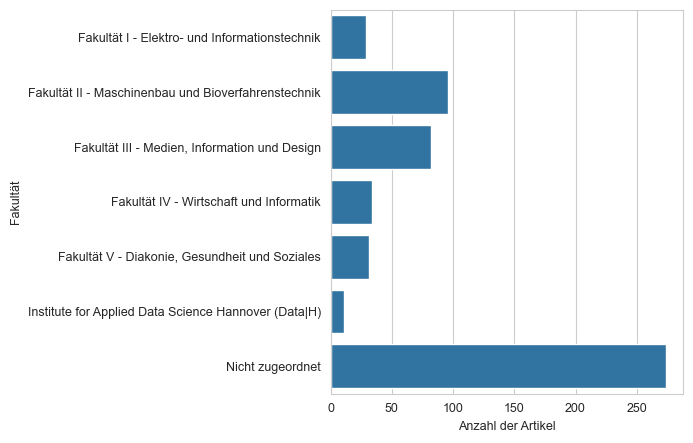

In [144]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [145]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5080789946140036

In [109]:
MAPPING_DICT_DEPT = {
    'Fakultät I - Elektro- und Informationstechnik': {
        #'Fachgebiet Elektrische Antriebe und Automatisierungstechnik': [],
        #'Fachgebiet Elektrische Anlagen': [],
        #'Fachgebiet Elektrische Messtechnik': [],
        #'Fachgebiet Grundlagen der Elektrotechnik': [],
        #'Fachgebiet Hochfrequenz- und Mikrowellentechnik': [],
        #'Fachgebiet Hochspannungstechnik': [],
        #'Fachgebiet Industrieelektronik und Digitaltechnik': [],
        #'Fachgebiet Ingenieurinformatik': [],
        #'Fachgebiet Kommunikationstechnik': [],
        #'Fachgebiet Physik': [],
        #'Fachgebiet Prozessinformatik und Automatisierungstechnik': [],
        #'Fachgebiet Regelungstechnik': [],
        #'Fachgebiet Technische Redaktion': [],
        #'Fachgebiet Technologie': [],
    },
    'Fakultät II - Maschinenbau und Bioverfahrenstechnik': {
        #'Abteilung Maschinenbau': [],
        #'Fachgebiet Automatisierungstechnik': [],
        #'Fachgebiet Förder- und Handhabungstechnik, Logistik und Materialflusstechnik (FHLM)': [],
        #'Fachgebiet Umformtechnik': [],
        'Fachgebiet Verfahrens-, Energie- und Umwelttechnik': ['verfahrenstechnik'],
        #'Fachgebiet Werkstoffkunde': [],
        'Institut für Biokunststoffe und Bioverbundwerkstoffe (ifBB)': ['bioplastics'],
        #'Labor Digitale Fabrik': [],
        #'Mechanische Verfahrenstechnik Labor (M-H-35-02)': [],
    },
    'Fakultät III - Medien, Information und Design': {
        #'Abteilung Design und Medien': [],
        #'Abteilung Information und Kommunikation': [],
    }
}

In [110]:
with open('./mapping_tables_dept/hsh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [111]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [112]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fakultät III - Medien, Information und Design')

In [113]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['University of Applied Sciences and Arts Hanover, Expo Plaza 12, 30559 Hannover, Germany',
       'Department of Information and Communication, Faculty for Media, Information and Design, University of Applied Sciences and Arts Hannover, Hannover, Germany',
       'Department of Information and Communication, Faculty for Media, Information and Design University of Applied Sciences and Arts Hannover  Hannover Germany',
       'Hochschule Hannover Expo Plaza 12 30539 Hannover, Germany',
       'Fakultat III, Hochschule Hannover - University of Applied Sciences and Arts, Expo Plaza, Hannover, 30539, Lower Saxony, Germany',
       'Faculty III, Hochschule Hannover University of Applied Sciences & Arts, Hannover, Lower Saxony, Germany',
       'UNIRED Research Group, Faculty III, Hochschule Hannover University of Applied Sciences & Arts, Lower Saxony, 30159, Hannover, Germany',
       'Department of Information and Communication, Faculty for Media, Information and Design, University o

In [114]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,NaN,82


In [115]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
8,"Fakultät III - Medien, Information und Design",Hochschule Hannover,University of Applied Sciences and Arts Hanove...,https://openalex.org/W4207051111,None
11,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Department of Information and Communication, F...",https://openalex.org/W4282973240,None
12,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Department of Information and Communication, F...",https://openalex.org/W4282973240,None
15,"Fakultät III - Medien, Information und Design",Hochschule Hannover,Hochschule Hannover Expo Plaza 12 30539 Hannov...,https://openalex.org/W4285209254,None
18,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Fakultat III, Hochschule Hannover - University...",https://openalex.org/W4280607052,None
...,...,...,...,...,...
525,"Fakultät III - Medien, Information und Design",Hochschule Hannover,Hochschule Hannover Fakultat III Medien Inform...,https://openalex.org/W3117263165,None
527,"Fakultät III - Medien, Information und Design",Hochschule Hannover,Hochschule Hannover – University of Applied Sc...,https://openalex.org/W3114667184,None
528,"Fakultät III - Medien, Information und Design",Hochschule Hannover,Institute of Biometry and Clinical Epidemiolog...,https://openalex.org/W3114667184,None
539,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"University of Applied Sciences Hannover, Hochs...",https://openalex.org/W3198810427,None
